In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [3]:
df.shape

(3554, 18)

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ats triumph,sector 104,4.45,6846.0,4,5,3+,27.0,Relatively New,7222.0,0,0,0,0,0,1,110
1,flat,dlf new town heights,sector 86,1.26,6114.0,3,3,3,5.0,Moderately Old,1747.0,0,1,0,0,1,1,113
2,flat,oriental valley chs,sector 9a,1.50,9091.0,4,3,3+,8.0,Relatively New,1833.0,0,0,0,0,0,0,8
3,flat,ramprastha the edge towers,sector 37d,0.75,5319.0,2,2,3,19.0,Moderately Old,1410.0,0,0,0,0,0,1,63
4,flat,microtek greenburg,sector 86,1.45,9797.0,3,2,3,8.0,Relatively New,1480.0,0,0,0,0,0,2,72


In [6]:
latlong = pd.read_csv("latlong.csv")

In [7]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [8]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [9]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [10]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [11]:
new_df = df.merge(latlong , on = 'sector')

In [14]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3293 entries, 0 to 3292
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3293 non-null   object 
 1   society          3293 non-null   object 
 2   sector           3293 non-null   object 
 3   price            3293 non-null   float64
 4   price_per_sqft   3293 non-null   float64
 5   bedRoom          3293 non-null   int64  
 6   bathroom         3293 non-null   int64  
 7   balcony          3293 non-null   object 
 8   floorNum         3293 non-null   float64
 9   agePossession    3293 non-null   object 
 10  built_up_area    3293 non-null   float64
 11  study room       3293 non-null   int64  
 12  servant room     3293 non-null   int64  
 13  store room       3293 non-null   int64  
 14  pooja room       3293 non-null   int64  
 15  others           3293 non-null   int64  
 16  furnishing_type  3293 non-null   int64  
 17  luxury_score  

In [15]:
group_df = new_df.groupby('sector')[['price' , 'price_per_sqft' , 'built_up_area' , 'latitude' , 'longitude']].mean()

In [16]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.964286,5489.428571,2030.485714,28.3515,76.9428
sector 1,1.141333,5130.766667,2086.733333,28.3663,76.9456
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
sector 103,1.495000,7445.785714,1865.428571,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.934000,5928.290000,1571.341800,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326
sector 95,0.480545,5602.509091,995.981818,28.4172,76.9081


C:\Users\virat\AppData\Local\Temp\ipykernel_1080\860414701.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',


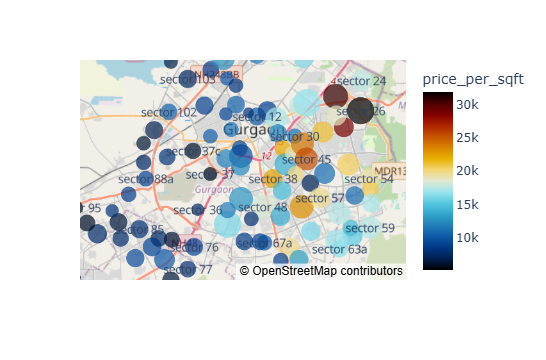

In [17]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [18]:
new_df.to_csv('data_viz1.csv',index=False)

In [19]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [20]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,4 BHK Flat in Sector 104 Gurgaon,flat,ats triumph,4.45,6846.0,6500.0,Carpet area: 6500 (603.87 sq.m.),4,5,3+,not available,"N/a, Sector 104 Gurgaon, Gurgaon, Haryana",27.0,North,1 to 5 Year Old,"['IFFCO Chowk Metro Station', 'The Esplanade M...",Ats triumph is one of the most popular destina...,[],"['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Green Area4 out of 5', 'Construction5 out of..."
1,4 Bedroom House for sale in Nirvana Country,house,Unitech Escape3.8 ★,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,"servant room,study room,pooja room,store room","123, Nirvana Country, Gurgaon, Haryana",2.0,North,1 to 5 Year Old,"['Sector 55-56 Metro Station', 'Airia Mall', '...",The villa is very good location and 100% power...,"['5 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Ge...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment5 out of 5', 'Safety5 out of 5', ..."
2,3 BHK Flat in Sector 86 Gurgaon,flat,dlf new town heights,1.26,6113.0,2061.0,Super Built up area 1930(179.3 sq.m.),3,3,3,"others,servant room","Multiple Options In, Sector 86 Gurgaon, Gurgao...",5.0,West,5 to 10 Year Old,"['City Square', 'Vatika Town Square', 'Bharat ...",Call 95605 zero 9397 for more details and site...,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Green Area5 out of 5', 'Construction4.5 out ..."
3,4 BHK Flat in Sector 9A Gurgaon,flat,oriental valley chs,1.50,9090.0,1650.0,Carpet area: 1650 (153.29 sq.m.),4,3,3+,not available,"Flat No. 803, Sector 9A Gurgaon, Gurgaon, Haryana",8.0,NaN,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Esic...",Society with 25 flats with power back up. Flyo...,"['6 Fan', '1 Exhaust Fan', '3 Geyser', '12 Lig...",['Natural Light'],"['Safety4 out of 5', 'Lifestyle4 out of 5', 'E..."
4,2 BHK Flat in Sector 37D Gurgaon,flat,ramprastha the edge towers,0.75,5319.0,1410.0,Built Up area: 1410 (130.99 sq.m.),2,2,3,not available,"Sector 37d, Delhi Gurgaon Expressway, Sector 3...",19.0,NaN,5 to 10 Year Old,"['MDS Public School', 'St Pauls School', 'Sunc...","2 bath, unfurnished, 19th floor (Of 19), rampr...",NaN,NaN,"['Green Area4 out of 5', 'Construction4 out of..."


In [21]:
!pip install wordcloud


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from wordcloud import WordCloud

In [23]:
wordcloud_df = df1.merge(df , left_index = True , right_index = True)[['features' , 'sector']]

In [24]:
wordcloud_df.head()

,features,sector
0,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 104
1,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 86
2,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 9a
3,['Natural Light'],sector 37d
4,NaN,sector 86


In [25]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [26]:
main

['Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Internet/wi-fi connectivity',
 'Fitness Centre / GYM',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Water softening plant',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'Piped-gas',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Internet/wi-fi connectivity',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'Centrally Air Con

In [27]:
feature_text = ' '.join(main)

In [28]:
feature_text

'Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Visitor Parking Swimming Pool Park Security Personnel Internet/wi-fi connectivity Fitness Centre / GYM Rain Water Harvesting Club house / Community Center Water softening plant Feng Shui / Vaastu Compliant Private Garden / Terrace High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room Piped-gas Visitor Parking Swimming Pool Park Security Personnel Internet/wi-fi connectivity Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Security / Fire Alarm Feng Shui / Vaastu Compliant Intercom Facility Lift(s) Centrally Air Conditioned Maintenance Staff Water Storage Separate entry for servant room No open drainage around Piped-gas Visitor Parking Swimming Pool Park Security Personnel Natu

In [29]:
import pickle
pickle.dump(feature_text , open('feature_text.pkl' , 'wb'))

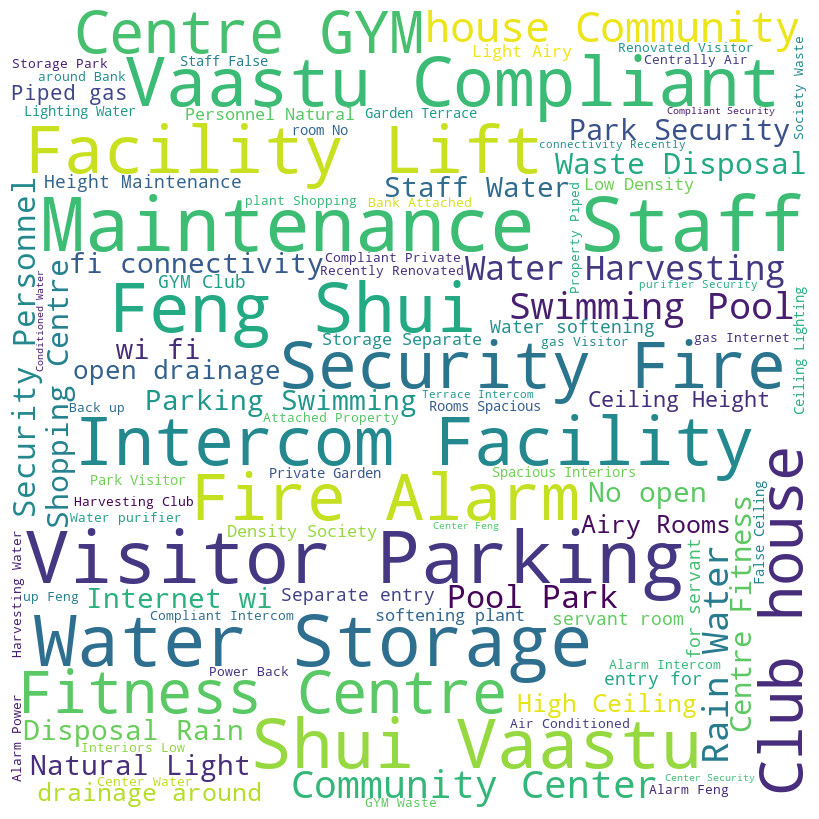

In [30]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

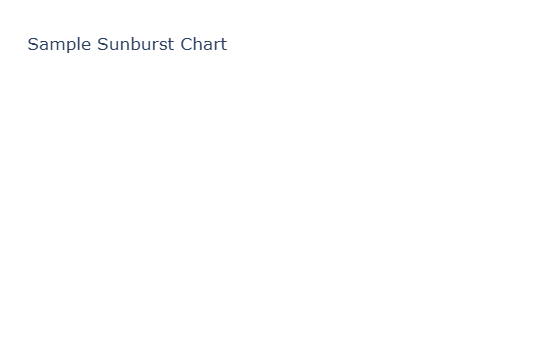

In [31]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

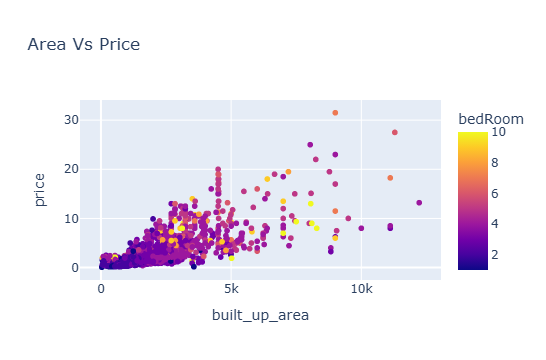

In [32]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

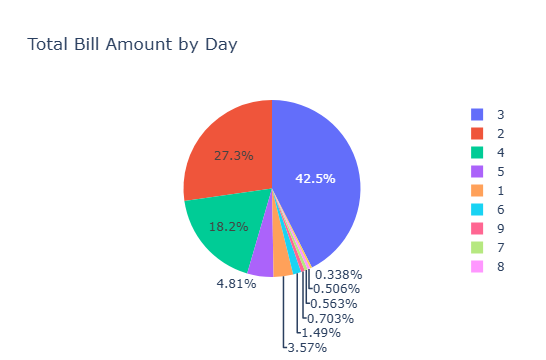

In [33]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

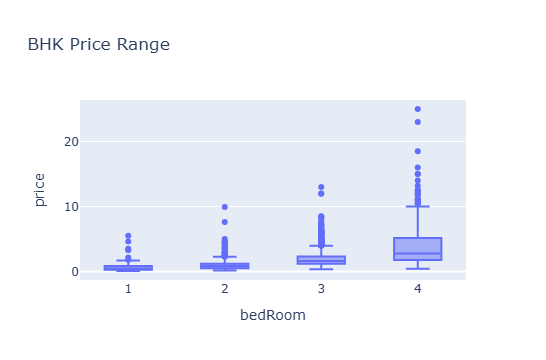

In [34]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()

C:\Users\virat\AppData\Local\Temp\ipykernel_1080\3761596323.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['property_type'] == 'house']['price'])
C:\Users\virat\AppData\Local\Temp\ipykernel_1080\3761596323.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['property_type'] == '

<Axes: xlabel='price', ylabel='Density'>

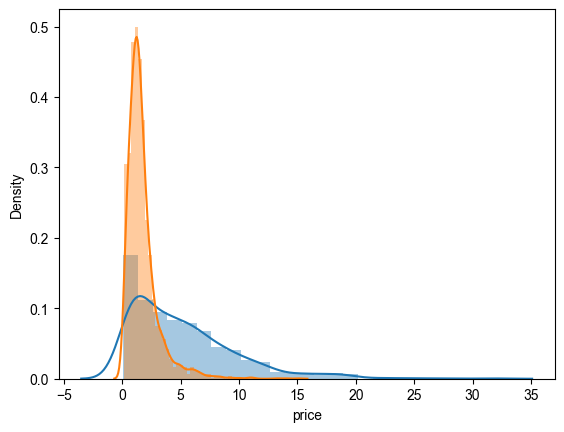

In [35]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])

In [36]:
new_df['sector'].unique().tolist().insert(0,'overall')